## 02. EDA
> パイプライン位置: 01_data_collection → `02_eda` → 03_sql → 04_modeling

---

## 主要変数

| 変数 | 役割 | 備考 |
|---|---|---|
| egg_price | Target | 鶏卵小売価格（特選卵30個基準） | 
| feed_ppi | 主要コスト Feature | 養鶏用配合飼料 生産者物価指数 | 
| electricity_ppi | 補助コスト Feature | 産業用電力 生産者物価指数 | 
| egg_ppi / egg_cpi | EDA 参照用変数 | 内生性問題によりモデルのFeatureから除外 | 


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys
import os

sys.path.append(os.path.abspath('..'))

from src.db.connection import engine

df_kamis = pd.read_sql("SELECT * FROM kamis_egg_retail", engine)
df_ecos = pd.read_sql("SELECT * FROM ecos_ppi", engine)

print(df_kamis.dtypes)
print(df_kamis.head())
print(df_ecos.head())

year_month    datetime64[us]
egg_price              int64
dtype: object
  year_month  egg_price
0 2016-01-01       5493
1 2016-02-01       5473
2 2016-03-01       5260
3 2016-04-01       5259
4 2016-05-01       5216
  year_month  egg_ppi  electricity_ppi  feed_ppi  egg_cpi
0 2016-01-01    92.17            98.81     95.69   92.594
1 2016-02-01    85.08            98.81     95.69   91.098
2 2016-03-01    83.52            98.81     94.82   87.269
3 2016-04-01    89.81            98.81     94.82   86.773
4 2016-05-01    85.53            98.81     94.82   84.645


In [2]:
df = pd.merge(df_kamis, df_ecos, on='year_month', how='inner')

print(df.shape)  
print(df.head())
print(df.isnull().sum())

(120, 6)
  year_month  egg_price  egg_ppi  electricity_ppi  feed_ppi  egg_cpi
0 2016-01-01       5493    92.17            98.81     95.69   92.594
1 2016-02-01       5473    85.08            98.81     95.69   91.098
2 2016-03-01       5260    83.52            98.81     94.82   87.269
3 2016-04-01       5259    89.81            98.81     94.82   86.773
4 2016-05-01       5216    85.53            98.81     94.82   84.645
year_month         0
egg_price          0
egg_ppi            0
electricity_ppi    0
feed_ppi           0
egg_cpi            0
dtype: int64


In [3]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   year_month       120 non-null    datetime64[us]
 1   egg_price        120 non-null    int64         
 2   egg_ppi          120 non-null    float64       
 3   electricity_ppi  120 non-null    float64       
 4   feed_ppi         120 non-null    float64       
 5   egg_cpi          120 non-null    float64       
dtypes: datetime64[us](1), float64(4), int64(1)
memory usage: 5.8 KB
None


In [4]:
print(df.describe())

                year_month    egg_price     egg_ppi  electricity_ppi  \
count                  120   120.000000  120.000000       120.000000   
mean   2020-12-15 18:00:00  6141.883333  129.260000       119.218917   
min    2016-01-01 00:00:00  4037.000000   59.600000        97.200000   
25%    2018-06-23 12:00:00  5323.500000   98.702500       100.000000   
50%    2020-12-16 12:00:00  6313.500000  139.965000       100.000000   
75%    2023-06-08 12:00:00  6704.000000  153.687500       148.880000   
max    2025-12-01 00:00:00  9096.000000  196.800000       174.670000   
std                    NaN   931.262856   34.069246        28.702335   

         feed_ppi     egg_cpi  
count  120.000000  120.000000  
mean   114.028333  118.554850  
min     94.380000   82.984000  
25%     95.907500   97.403000  
50%    100.440000  131.400000  
75%    134.067500  136.585000  
max    145.600000  154.350000  
std     19.163926   22.309603  


- matplotlibでは日本語が文字化けするため、日本語フォントを指定した。

In [5]:
import matplotlib.font_manager as fm
plt.rcParams['font.family'] = 'YuMincho'
plt.rcParams['axes.unicode_minus'] = False

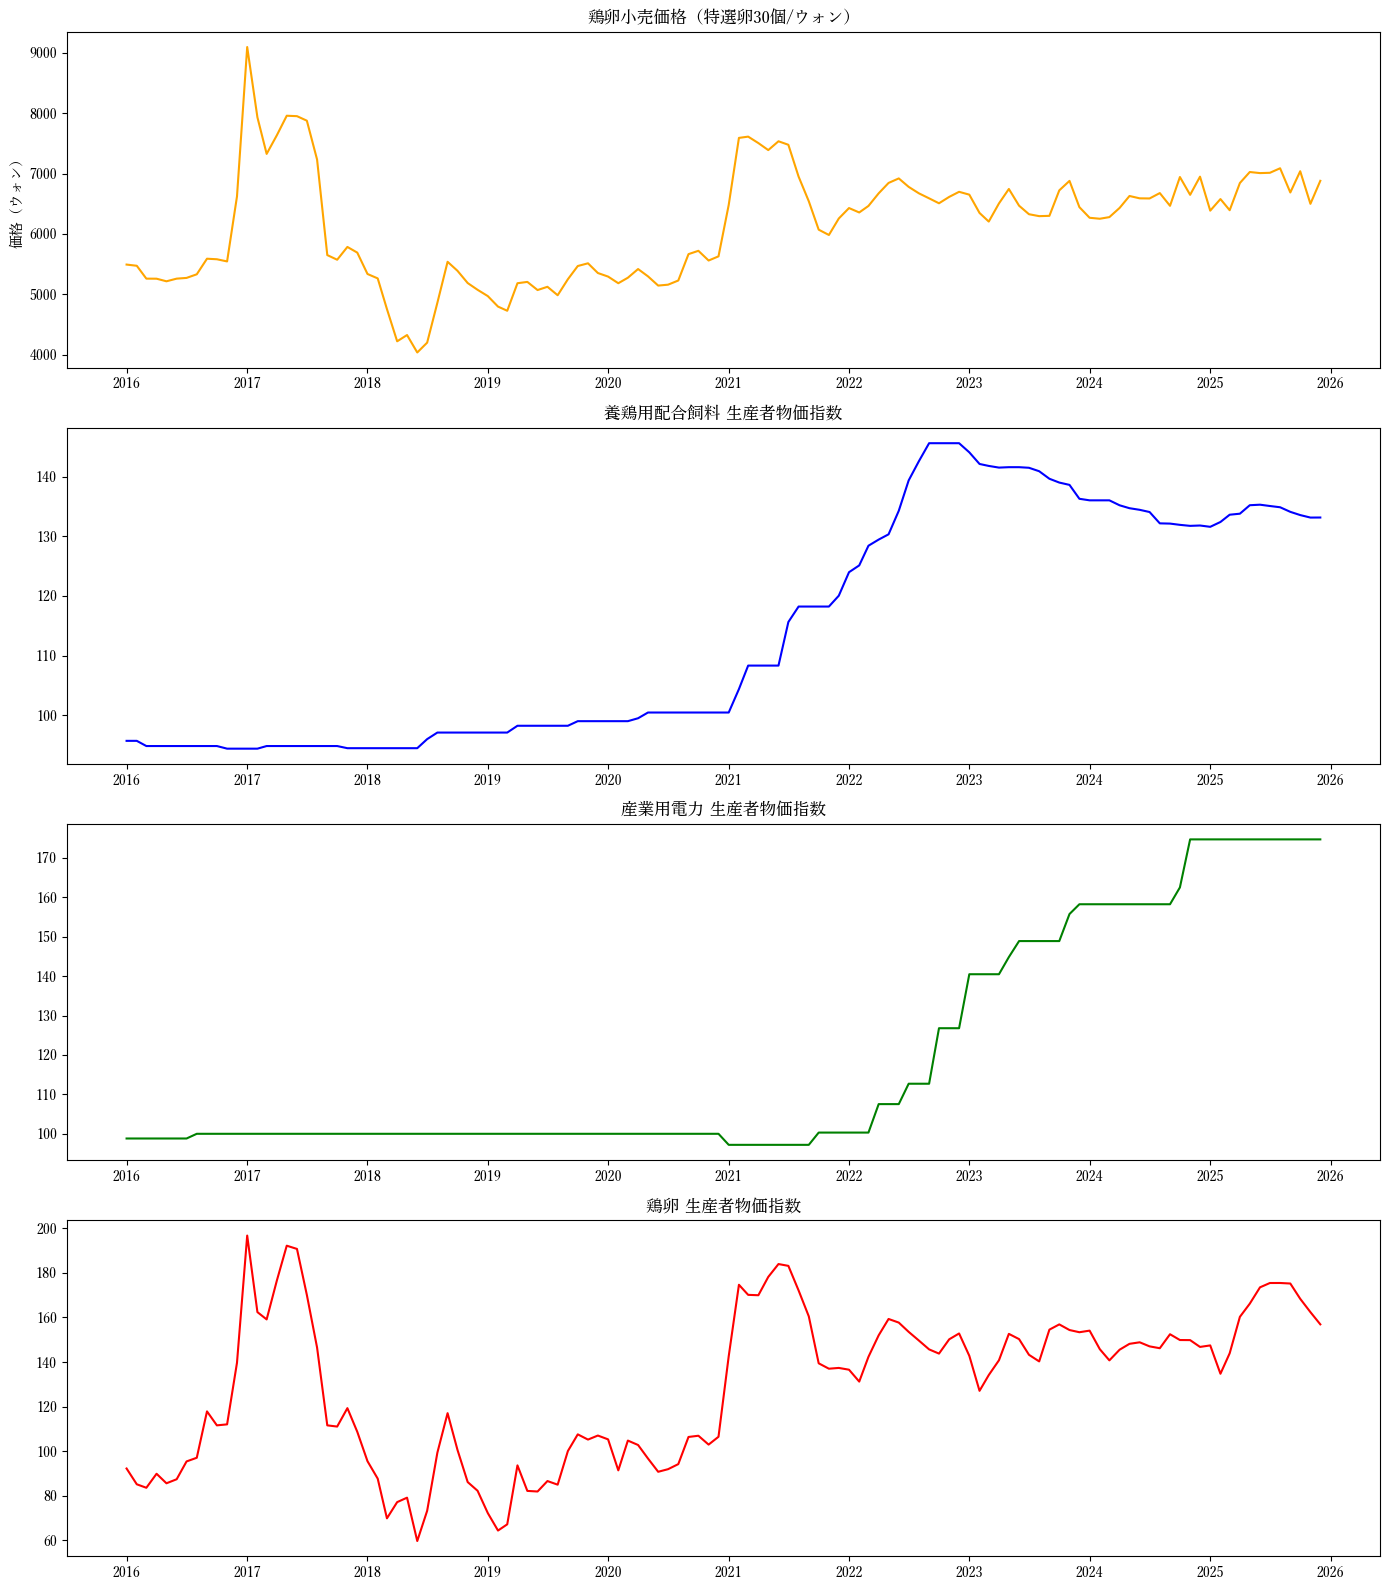

In [ ]:
plt.close('all') 

fig, axes = plt.subplots(4, 1, figsize=(14, 16))

axes[0].plot(df['year_month'], df['egg_price'], color='orange')
axes[0].set_title('鶏卵小売価格（特選卵30個/ウォン）')
axes[0].set_ylabel('価格（ウォン）')

axes[1].plot(df['year_month'], df['feed_ppi'], color='blue')
axes[1].set_title('養鶏用配合飼料 生産者物価指数')

axes[2].plot(df['year_month'], df['electricity_ppi'], color='green')
axes[2].set_title('産業用電力 生産者物価指数')

axes[3].plot(df['year_month'], df['egg_ppi'], color='red')
axes[3].set_title('鶏卵 生産者物価指数')

# egg_cpiはegg_ppiと相関r=0.94のためここでは除外。
# 相関についてはヒートマップで確認できる。

plt.tight_layout()
plt.savefig('../output/figures/time_series_all.png', dpi=150)
plt.show()

> 2021年以降、鶏卵小売価格・飼料・電力PPIが連動して上昇。      
> 2017年AI発生期にはコスト動向と乖離した価格急騰が観察された。

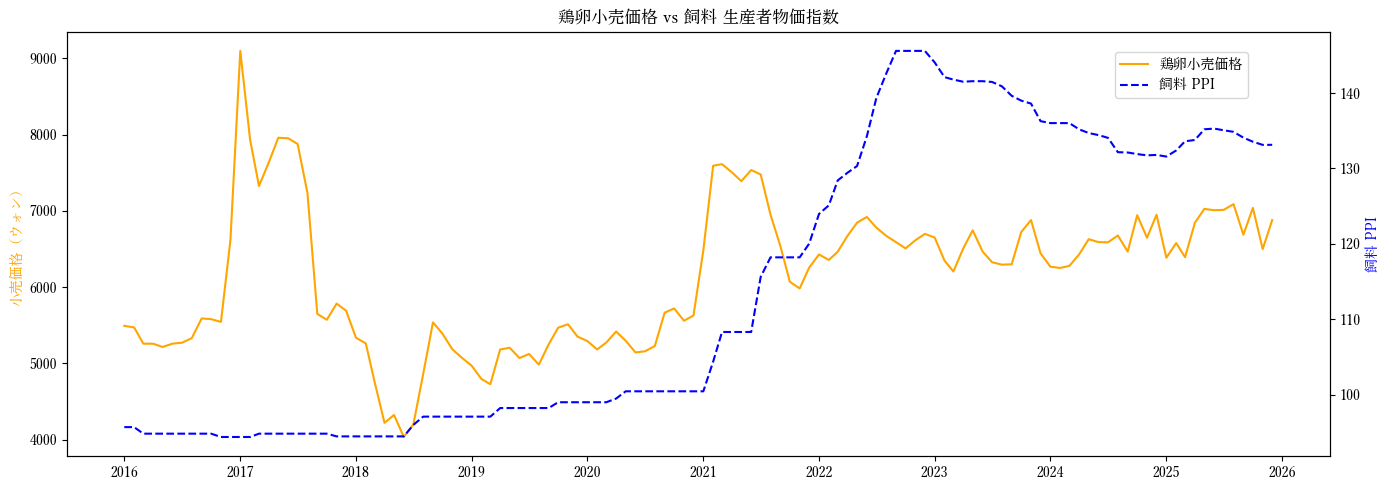

In [7]:
plt.close('all') 

fig, ax1 = plt.subplots(figsize=(14, 5))

ax1.plot(df['year_month'], df['egg_price'],
         color='orange', label='鶏卵小売価格')
ax1.set_ylabel('小売価格（ウォン）', color='orange')

ax2 = ax1.twinx()
ax2.plot(df['year_month'], df['feed_ppi'],
         color='blue', linestyle='--', label='飼料 PPI')
ax2.set_ylabel('飼料 PPI', color='blue')

plt.title('鶏卵小売価格 vs 飼料 生産者物価指数')
fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.90))

plt.tight_layout()
plt.savefig('../output/figures/egg_vs_feed.png', dpi=150)
plt.show()

> 飼料PPI上昇局面で鶏卵小売価格も概ね連動。   
>特に2021年以降は飼料費急騰とともに価格上昇幅も拡大した。

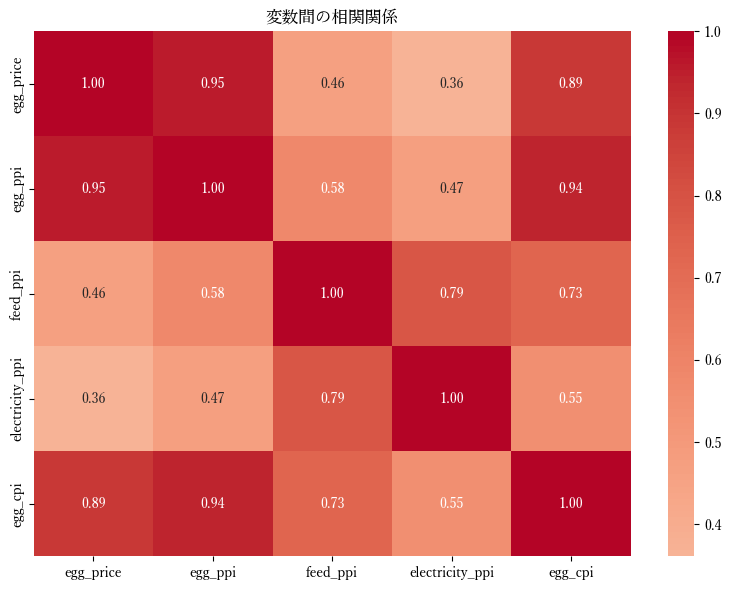

In [8]:
plt.close('all') 

corr = df[['egg_price', 'egg_ppi', 'feed_ppi',
           'electricity_ppi', 'egg_cpi']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f',
            cmap='coolwarm', center=0)

plt.title('変数間の相関関係')
plt.tight_layout()
plt.savefig('../output/figures/correlation_heatmap.png', dpi=150)
plt.show()

> egg_ppiはegg_priceと相関0.95のため、内生性問題でFeatureから除外した。   
> feed_ppiの相関0.46はelectricity_ppiの相関0.36より高い相関を示した。

In [9]:
df['price_change_pct'] = df['egg_price'].pct_change() * 100

outliers = df[df['price_change_pct'].abs() > 10]
print("急騰・急落区間:")
print(outliers[['year_month', 'egg_price', 'price_change_pct']])

急騰・急落区間:
   year_month  egg_price  price_change_pct
11 2016-12-01       6621         19.404869
12 2017-01-01       9096         37.381060
13 2017-02-01       7932        -12.796834
20 2017-09-01       5650        -21.885801
27 2018-04-01       4222        -11.227923
31 2018-08-01       4860         15.714286
32 2018-09-01       5539         13.971193
60 2021-01-01       6481         15.135903
61 2021-02-01       7591         17.126987


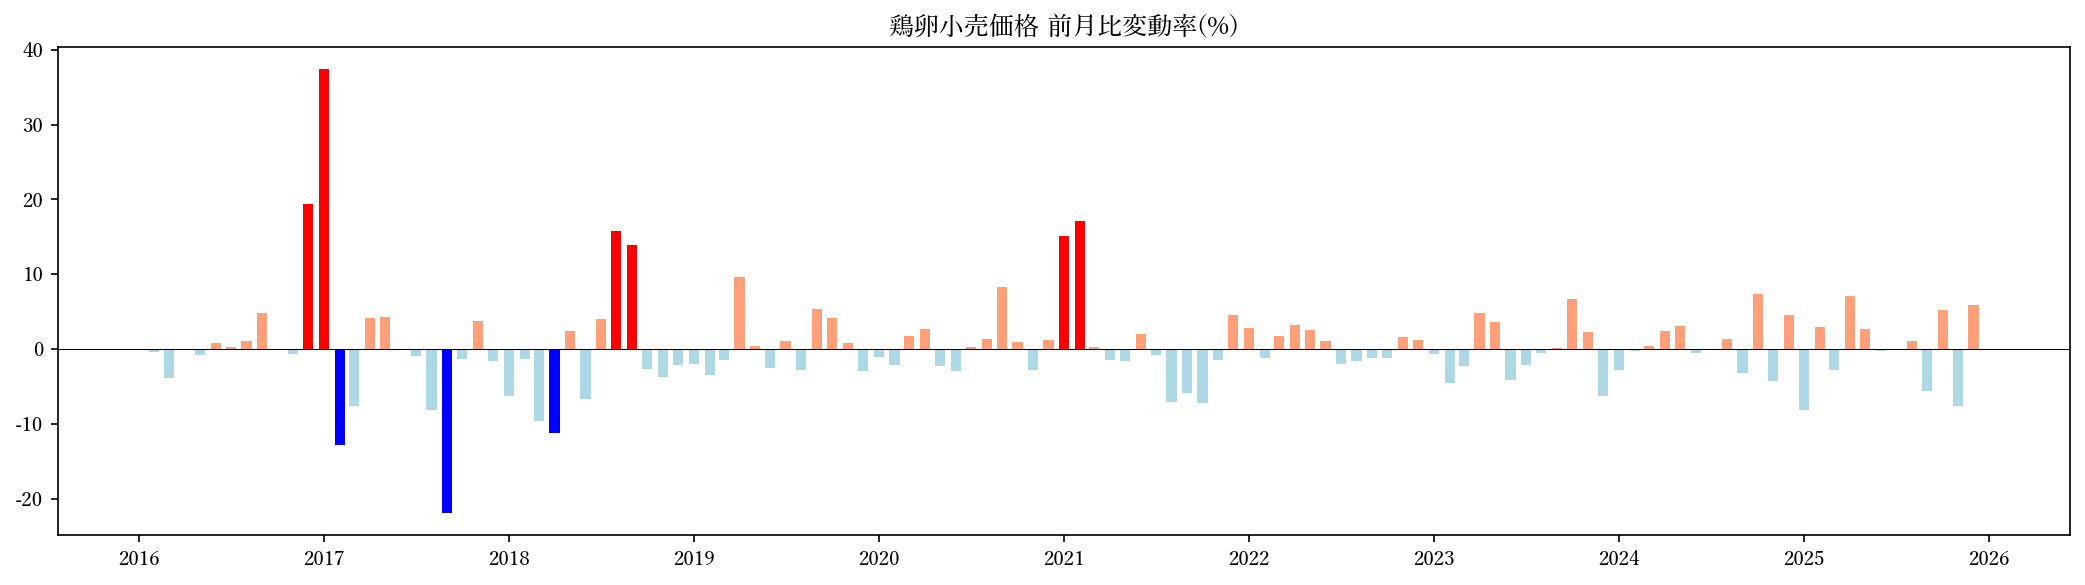

In [10]:
df['is_outlier'] = df['price_change_pct'].abs() > 10

plt.close('all') 
plt.figure(figsize=(14, 4), dpi=150)

plt.bar(
    df['year_month'],
    df['price_change_pct'],
    width=20,  
    color=df.apply(
        lambda row: ('red' if row['price_change_pct'] > 0 else 'blue') 
                    if row['is_outlier'] 
                    else ('lightsalmon' if row['price_change_pct'] > 0 else 'lightblue'),
        axis=1
    ),
)

plt.axhline(y=0, color='black', linewidth=0.5)
plt.title('鶏卵小売価格 前月比変動率(%)')
plt.tight_layout()
plt.savefig('../output/figures/price_change.png', dpi=150)
plt.show()

> ±10%超の急騰・急落はAI発生区間の供給ショックに集中しているが、   
> 2017年後半〜2018年の急落は殺虫剤パニックによる需要崩壊に起因しており、     
> 外部ショックは供給・需要の両面から価格を撹乱しうることが確認された。       

In [11]:
print(df['year_month'].dtype)
print(df['year_month'].head())

datetime64[us]
0   2016-01-01
1   2016-02-01
2   2016-03-01
3   2016-04-01
4   2016-05-01
Name: year_month, dtype: datetime64[us]


IQR基準の外れ値: 1件
   year_month  egg_price
12 2017-01-01       9096


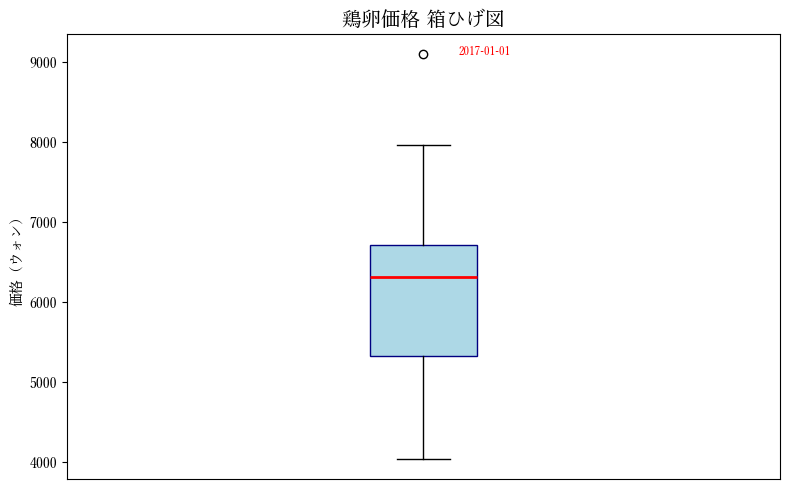

In [12]:
Q1 = df['egg_price'].quantile(0.25)
Q3 = df['egg_price'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['egg_price'] < lower) | 
              (df['egg_price'] > upper)]

print(f"IQR基準の外れ値: {len(outliers)}件")
print(outliers[['year_month', 'egg_price']])

plt.close('all') 
fig, ax = plt.subplots(figsize=(8, 5))

ax.boxplot(df['egg_price'].dropna(), vert=True, patch_artist=True,
           boxprops=dict(facecolor='lightblue', color='navy'),
           medianprops=dict(color='red', linewidth=2),
           flierprops=dict(marker='o', color='red', markersize=6))

for _, row in outliers.iterrows():
    ax.annotate(str(row['year_month'])[:10], 
                xy=(1, row['egg_price']),
                xytext=(1.05, row['egg_price']),
                fontsize=8, color='red')

ax.set_title('鶏卵価格 箱ひげ図', fontsize=14)
ax.set_ylabel('価格（ウォン）')
ax.set_xticks([]) 

plt.tight_layout()
plt.savefig('../output/figures/outlier_egg_price_boxplot.png', dpi=150)
plt.show()

> 2017年1月がIQR基準の外れ値として検出された。   
> AI拡散による実市場価格急騰区間と判断し、除去せずダミー変数として反映する。

- 標本数が120件程度と少ないため、正規性検定にはShapiro-Wilkを使用した。   
Q-Q Plotは外れ値の影響を視覚的に確認するために併用した。

Shapiro-Wilk 検定
統計量: 0.9743
p-value: 0.0211
正規分布に従わない (p < 0.05)


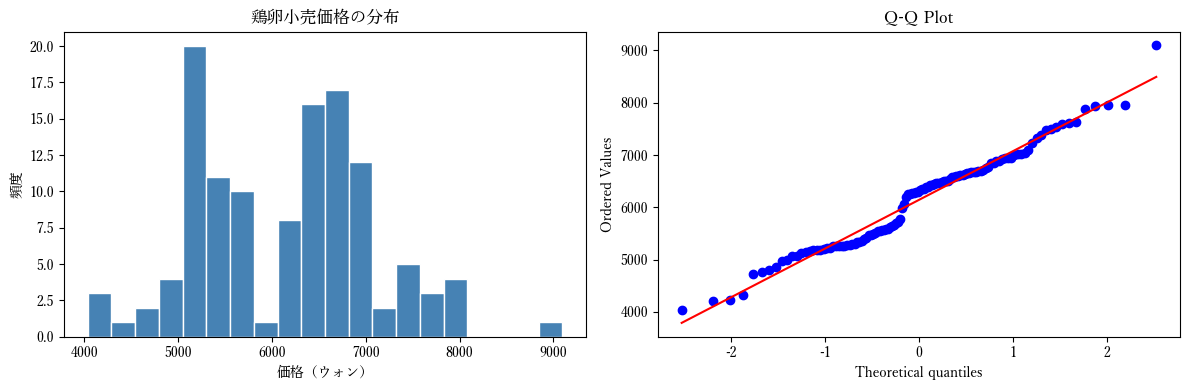

In [13]:
from scipy import stats

stat, p_value = stats.shapiro(df['egg_price'])
print(f"Shapiro-Wilk 検定")
print(f"統計量: {stat:.4f}")
print(f"p-value: {p_value:.4f}")

if p_value > 0.05:
    print("正規分布に従う (p > 0.05)")
else:
    print("正規分布に従わない (p < 0.05)")

plt.close('all') 

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['egg_price'], bins=20, color='steelblue', edgecolor='white')
axes[0].set_title('鶏卵小売価格の分布')
axes[0].set_xlabel('価格（ウォン）')
axes[0].set_ylabel('頻度')

stats.probplot(df['egg_price'], dist="norm", plot=axes[1])
axes[1].set_title('Q-Q Plot')

plt.tight_layout()
plt.savefig('../output/figures/normality_check.png', dpi=150)
plt.show()

> 価格分布は2つの価格帯が混在する形状を示し、正規分布に従わなかった。   
>Q-Q Plotでも、AIショック区間に起因する右裾の広がりと外れ値が確認された。

- ラグが長くなるにつれ欠損行が増えるため、6ヶ月を上限とした。

In [14]:
print("===  飼料費 ラグ別相関係数 ===")
for lag in range(7):
    corr = df['egg_price'].corr(df['feed_ppi'].shift(lag))
    print(f"飼料費 {lag}ヶ月ラグ: {corr:.3f}")

print("\n=== 電力費 ラグ別相関係数 ===")
for lag in range(7):
    corr = df['egg_price'].corr(df['electricity_ppi'].shift(lag))
    print(f"電力費 {lag}ヶ月ラグ: {corr:.3f}")

===  飼料費 ラグ別相関係数 ===
飼料費 0ヶ月ラグ: 0.462
飼料費 1ヶ月ラグ: 0.446
飼料費 2ヶ月ラグ: 0.433
飼料費 3ヶ月ラグ: 0.420
飼料費 4ヶ月ラグ: 0.409
飼料費 5ヶ月ラグ: 0.397
飼料費 6ヶ月ラグ: 0.384

=== 電力費 ラグ別相関係数 ===
電力費 0ヶ月ラグ: 0.361
電力費 1ヶ月ラグ: 0.352
電力費 2ヶ月ラグ: 0.345
電力費 3ヶ月ラグ: 0.340
電力費 4ヶ月ラグ: 0.335
電力費 5ヶ月ラグ: 0.329
電力費 6ヶ月ラグ: 0.322


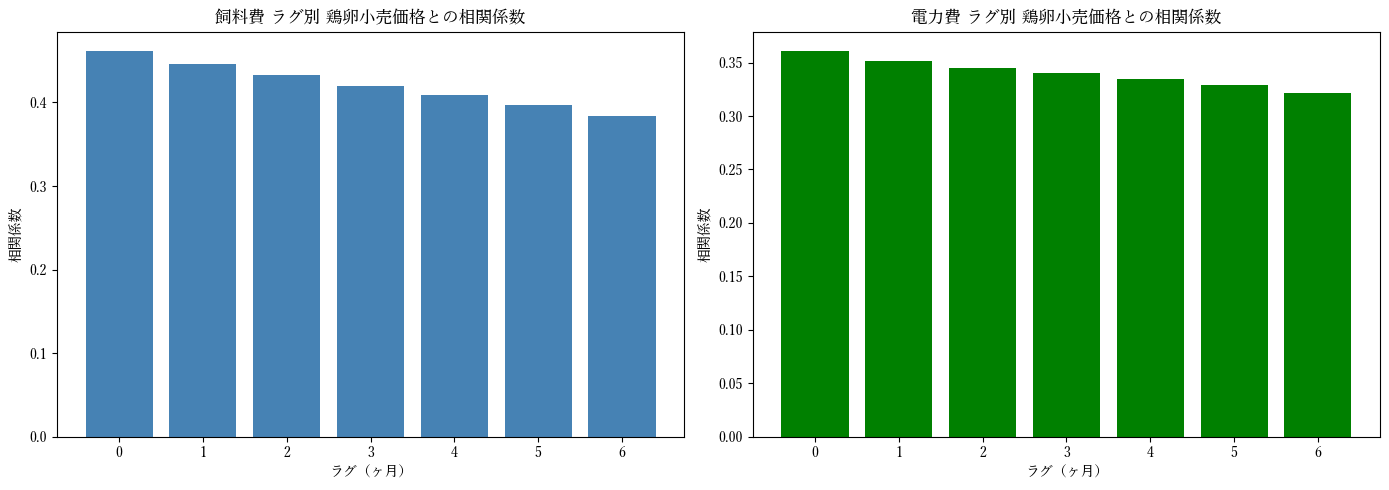

In [15]:
lags = range(7)

feed_corrs = [df['egg_price'].corr(df['feed_ppi'].shift(lag)) for lag in lags]
elec_corrs = [df['egg_price'].corr(df['electricity_ppi'].shift(lag)) for lag in lags]

plt.close('all') 

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(lags, feed_corrs, color='steelblue')
axes[0].set_xlabel('ラグ（ヶ月）')
axes[0].set_ylabel('相関係数')
axes[0].set_title('飼料費 ラグ別 鶏卵小売価格との相関係数')
axes[0].set_xticks(list(lags))

axes[1].bar(lags, elec_corrs, color='green')
axes[1].set_xlabel('ラグ（ヶ月）')
axes[1].set_ylabel('相関係数')
axes[1].set_title('電力費 ラグ別 鶏卵小売価格との相関係数')
axes[1].set_xticks(list(lags))

plt.tight_layout()
plt.savefig('../output/figures/lag_correlation.png', dpi=150)
plt.show()

> 飼料費と電力費ともに全区間で単調減少した。   
> 明確なカットオフがないため、データ損失と説明力のバランスを考慮しLAG 1〜3を採用する。 

## EDAに基づく仮説

| 仮説 | 内容 |
|---|---|
| H1 | 飼料費はラグなしで鶏卵小売価格に即時転嫁される。 |
| H2 | 飼料費は電力費より鶏卵価格に大きな影響を与える。 | 
| H3 | AI発生期間では、コスト以外の外部ショック要因が価格を支配する。| 

## EDA 要約・モデリング方針

飼料費は電力費より鶏卵価格との相関が高く、LAG 1〜3でも同様の傾向が維持された。      
一方、AI発生時期にはコストの動きだけでは説明できない急激な価格変動が確認された。      
04_modelingではLAG 1〜3の変数とAIダミー変数を追加してモデリングを実施する。      